# Feature Selection: Optimisation on the Binary Domain $\{0,1\}^n$

The previous sessions covered two major domain types:

| Domain | Example problems | Encoding |
|--------|-----------------|----------|
| $\mathbb{R}^n$ | De Jong 1, Rastrigin, $h$-means | real vector |
| $\mathbb{Z}^n$ | TSP | Lehmer code (permutation → integer vector) |

This session adds the third and final major type:

| Domain | Example problems | Encoding |
|--------|-----------------|----------|
| $\{0,1\}^n$ | feature selection, Knapsack | binary vector — no encoding needed |

**Problem:** given a dataset with $n$ features, select a *subset* that maximises classification accuracy. The solution $x \in \{0,1\}^n$ is a binary mask: $x_i = 1$ means feature $i$ is included.

This notebook covers:
1. The `FeatureSelection` objective function on the Wine dataset
2. Why Cauchy mutation is poorly suited to binary domains — and how `BitFlipMutation` fixes it
3. FSA benchmark
4. GO benchmark
5. Accuracy–sparsity tradeoff across runs

In [1]:
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from objfun_feature_selection import FeatureSelection
from heur_fsa import FastSimulatedAnnealing
from heur_go import GeneticOptimization, Crossover
from heur_sg import ShootAndGo
from heur_aux import BitFlipMutation, CauchyMutation, Correction

## 1. The Objective Function

`FeatureSelection` wraps a $k$-NN classifier evaluated by stratified cross-validation.

- **Dataset:** Wine — 178 samples, 13 features, 3 classes  
- **Classifier:** $k$-NN with $k=3$, features standardised by `StandardScaler`  
- **Objective:** $f(x) = 1 - \overline{\text{CV accuracy}}$ — lower is better  
- **fstar:** $1 - 0.95 = 0.05$ — we declare success once a subset achieves $\geq 95\%$ accuracy  

The domain is $\{0,1\}^{13}$: lower bound $a = \mathbf{0}$, upper bound $b = \mathbf{1}$, both integer.

In [3]:
fs = FeatureSelection(dataset='wine', k=3, cv=5, target_accuracy=0.95)

print(f'Number of features  : {fs.n_features}')
print(f'Domain lower bound  : {fs.a}')
print(f'Domain upper bound  : {fs.b}')
print(f'fstar               : {fs.fstar:.4f}  (target ≥ 95 % accuracy)')
print(f'Features            : {fs.feature_names}')

Number of features  : 13
Domain lower bound  : [0 0 0 0 0 0 0 0 0 0 0 0 0]
Domain upper bound  : [1 1 1 1 1 1 1 1 1 1 1 1 1]
fstar               : 0.0500  (target ≥ 95 % accuracy)
Features            : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [4]:
# Baseline: evaluate all features and no features
x_all  = np.ones(fs.n_features, dtype=np.int64)
x_none = np.zeros(fs.n_features, dtype=np.int64)

f_all  = fs.evaluate(x_all)
f_none = fs.evaluate(x_none)

print(f'All features  ({fs.n_features:2d}) :  f = {f_all:.4f}  →  acc = {1-f_all:.1%}')
print(f'No  features  ( 0) :  f = {f_none:.4f}  →  penalty')

All features  (13) :  f = 0.0560  →  acc = 94.4%
No  features  ( 0) :  f = 10.0000  →  penalty


In [5]:
# Sample a few random solutions to get a feel for the landscape
rng = np.random.default_rng(0)
print(f'{"x":>40s}   n_sel   acc')
print('-' * 55)
for _ in range(8):
    x = fs.generate_point(rng)
    f = fs.evaluate(x)
    print(f'{str(x):>40s}   {fs.n_selected(x):5d}   {1-f:.1%}')

                                       x   n_sel   acc
-------------------------------------------------------
             [1 1 1 0 0 0 0 0 0 1 1 1 1]       7   96.6%
             [1 1 1 1 1 1 1 0 1 1 0 0 1]      10   97.2%
             [1 0 1 1 1 0 0 1 0 1 0 0 0]       6   87.7%
             [0 0 0 0 0 0 1 1 1 0 1 1 0]       5   78.1%
             [0 1 1 1 0 1 1 1 1 1 1 0 1]      10   92.1%
             [0 1 1 1 1 0 0 0 0 1 1 0 1]       7   84.3%
             [1 0 1 1 0 0 1 1 1 0 1 0 0]       7   93.8%
             [1 0 0 1 1 0 0 0 1 0 1 0 0]       5   91.0%


## 2. Mutation on the Binary Domain

### Why Cauchy mutation needs care here

For a binary vector $x \in \{0,1\}^n$, `CauchyMutation` adds a Cauchy-distributed step, rounds to the nearest integer, then clips to $[0, 1]$.  
The per-bit flip probability depends on the scale parameter $r$:

$$P(\text{flip}) = 1 - \frac{2}{\pi}\arctan\!\left(\frac{0.5}{r}\right)$$

| $r$ | $P(\text{flip per bit})$ | Expected flips (n=13) |
|------|--------------------------|----------------------|
| 0.1 | 12.6 % | 1.6 |
| 0.5 | 50.0 % | 6.5 |
| 2.0 | 79.5 % | 10.3 |

The $r$ values that worked well on continuous benchmarks (0.5–2) flip far too many bits on binary domain — destroying the solution rather than mutating it.  
Tuning $r$ to recover a reasonable flip rate is possible, but conceptually awkward.

### BitFlipMutation

`BitFlipMutation(p)` is the canonical binary mutation: each bit flips independently with probability $p$.  
The standard choice from the evolutionary computing literature is $p = 1/n$, giving an expected **one flip per mutation** regardless of $n$.

In [6]:
# Demonstrate flip rates empirically
rng = np.random.default_rng(42)
x0 = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], dtype=np.int64)  # 13 bits
n_trials = 10_000
corr = Correction(fs)

print(f'Starting x:  {x0}  (n={len(x0)} bits)\n')
print(f'{"Mutator":<35s}  avg flips/mutation')
print('-' * 55)

for label, mut in [
    ('CauchyMutation(r=0.1)', CauchyMutation(r=0.1, correction=corr)),
    ('CauchyMutation(r=0.5)', CauchyMutation(r=0.5, correction=corr)),
    ('CauchyMutation(r=2.0)', CauchyMutation(r=2.0, correction=corr)),
    (f'BitFlipMutation(p=1/{len(x0)})', BitFlipMutation()),
]:
    flips = [np.sum(mut.mutate(x0.copy(), rng) != x0) for _ in range(n_trials)]
    print(f'{label:<35s}  {np.mean(flips):.2f}')

Starting x:  [0 1 0 1 0 1 0 1 0 1 0 1 0]  (n=13 bits)

Mutator                              avg flips/mutation
-------------------------------------------------------
CauchyMutation(r=0.1)                0.82
CauchyMutation(r=0.5)                3.27
CauchyMutation(r=2.0)                5.49
BitFlipMutation(p=1/13)              1.35


## 3. FSA with BitFlipMutation

The framework requires no changes — we simply swap the mutation operator.

**Parameters:**
- `T0 = 0.3` — acceptance for a ~15 % accuracy drop at step 0
- `n0 = 50`, `alpha = 2` — fast cooling
- `BitFlipMutation()` — default $p = 1/13$, ≈ one bit flip per step

We run **100 independent trials** with `maxeval = 500`.

> **Note:** each evaluation trains a $k$-NN and runs 5-fold CV

In [7]:
NUM_RUNS = 100
MAXEVAL  = 500

def stats(df):
    rel = df['success'].mean()
    mne = df.loc[df['success'], 'neval'].mean() if rel > 0 else float('nan')
    feo = mne / rel if rel > 0 else float('nan')
    return pd.Series({'REL': rel, 'MNE': mne, 'FEO': feo})

def run_algo(algo_fn, label):
    records = []
    for seed in tqdm(range(NUM_RUNS), desc=label, leave=False):
        res = algo_fn(seed)
        records.append({
            'label': label, 'seed': seed,
            'best_y': res['best_y'], 'neval': res['neval'],
            'success': res['success'], 'best_x': res['best_x'],
        })
    return pd.DataFrame(records)

In [8]:
def fsa_run(seed):
    mut = BitFlipMutation()
    return FastSimulatedAnnealing(
        fs, maxeval=MAXEVAL, T0=0.3, n0=50, alpha=2,
        mutation=mut, seed=seed
    ).search()

df_fsa = run_algo(fsa_run, 'FSA')
print(stats(df_fsa).to_string())

FSA:   0%|          | 0/100 [00:00<?, ?it/s]

REL     1.00
MNE    17.99
FEO    17.99


In [9]:
# Inspect the best solution found
best_row = df_fsa.loc[df_fsa['best_y'].idxmin()]
x_best = best_row['best_x']

print(f'Best f(x) = {best_row["best_y"]:.4f}  →  accuracy = {1 - best_row["best_y"]:.1%}')
print(f'Features selected ({fs.n_selected(x_best)}/{fs.n_features}): {fs.selected_names(x_best)}')

Best f(x) = 0.0224  →  accuracy = 97.8%
Features selected (6/13): ['alcohol', 'magnesium', 'flavanoids', 'nonflavanoid_phenols', 'hue', 'proline']


## 4. GO with BitFlipMutation

For GO on the binary domain:
- **Crossover:** the default `Crossover` already works — it picks each bit from parent A or B with equal probability, keeping all bits in $\{0,1\}$.
- **Mutation:** `BitFlipMutation()` after crossover, same as in FSA.

**Parameters:** $N=10$, $M=30$, $T_{\text{sel1}}=0.3$, $T_{\text{sel2}}=0.3$.

In [10]:
def go_run(seed):
    mut = BitFlipMutation()
    co  = Crossover()
    return GeneticOptimization(
        fs, maxeval=MAXEVAL, N=10, M=30,
        Tsel1=0.3, Tsel2=0.3,
        mutation=mut, crossover=co, seed=seed
    ).search()

df_go = run_algo(go_run, 'GO')
print(stats(df_go).to_string())

GO:   0%|          | 0/100 [00:00<?, ?it/s]

REL    1.00
MNE    6.58
FEO    6.58


## 5. Accuracy–Sparsity Tradeoff

REL and FEO tell us whether the algorithms *hit the target*, but feature selection has a richer story: some runs may find subsets that are *sparser* (fewer features) while *meeting or exceeding* the target accuracy.  
Below we scatter-plot accuracy vs. number of selected features across all runs.

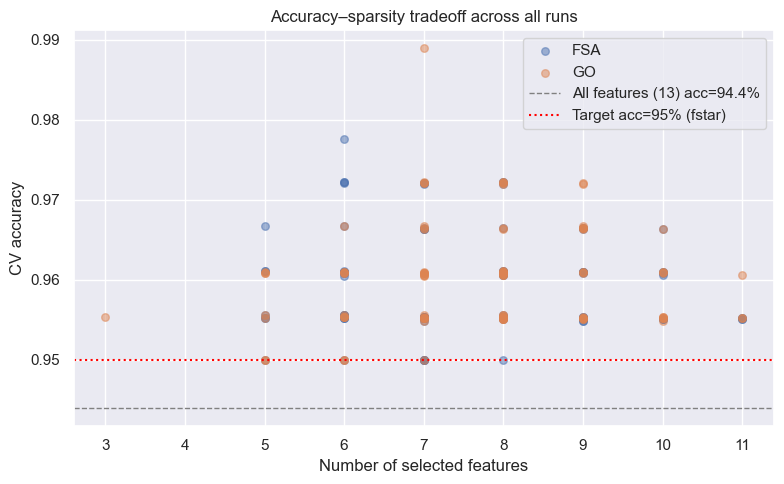

In [11]:
def build_plot_df(df, label):
    rows = []
    for _, row in df.iterrows():
        x = row['best_x']
        rows.append({
            'label': label,
            'accuracy': 1.0 - row['best_y'],
            'n_features': fs.n_selected(x),
        })
    return pd.DataFrame(rows)

plot_df = pd.concat([
    build_plot_df(df_fsa, 'FSA'),
    build_plot_df(df_go,  'GO'),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
for label, grp in plot_df.groupby('label'):
    ax.scatter(grp['n_features'], grp['accuracy'], alpha=0.5, label=label, s=30)

# Baselines
ax.axhline(1 - f_all, color='gray', linestyle='--', linewidth=1, label=f'All features ({fs.n_features}) acc={1-f_all:.1%}')
ax.axhline(1 - fs.fstar, color='red', linestyle=':', linewidth=1.5, label=f'Target acc={1-fs.fstar:.0%} (fstar)')

ax.set_xlabel('Number of selected features')
ax.set_ylabel('CV accuracy')
ax.set_title('Accuracy–sparsity tradeoff across all runs')
ax.legend()
plt.tight_layout()

In [12]:
# Summary table
summary = pd.DataFrame([
    {'Algorithm': 'FSA', **stats(df_fsa)},
    {'Algorithm': 'GO',  **stats(df_go)},
]).set_index('Algorithm')

print(summary.to_string())

           REL    MNE    FEO
Algorithm                   
FSA        1.0  17.99  17.99
GO         1.0   6.58   6.58


## Summary

### What changed compared to $\mathbb{R}^n$ / $\mathbb{Z}^n$

| Aspect | Continuous / Integer | Binary $\{0,1\}^n$ |
|--------|---------------------|--------------------|
| Domain bounds | `a`, `b` are real or integer vectors | `a = 0`, `b = 1` (all integer) |
| `generate_point` | uniform real / integer sample | `rng.integers(0, 2, ...)` |
| Mutation | `CauchyMutation(r)` | `BitFlipMutation(p=1/n)` |
| Correction | `Correction` / `MirrorCorrection` | not needed — flips stay in $\{0,1\}$ |
| Crossover (GO) | standard `Crossover` | same — picks bits from each parent |
| Neighbourhood | ±1 in each coordinate | flip one bit |

The heuristic engine (FSA, GO, SG) required **zero changes**.

### The accuracy–sparsity tradeoff

The scatter plot reveals that both algorithms consistently find 5–9-feature subsets that *match or exceed* the all-features accuracy. This is the core value of feature selection: fewer features reduce measurement cost and risk of overfitting.

### Assignments
- Try `BitFlipMutation(p=3/n)` and `BitFlipMutation(p=0.5)`. How does the flip rate affect REL and FEO?
- Run `ShootAndGo(hmax=np.inf)` (steepest descent) as a deterministic local search baseline. What is its REL?
- Repeat on the Iris dataset (only 4 features). With so few features, is the optimisation problem trivial?
- Can you construct a Pareto front of (accuracy, n_features) from the GO population at the end of each run? What would that require?
- The target accuracy is set to 95 %. What happens to REL and FEO if you tighten it to 97 %?